In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
np.random.seed(42)
X = np.random.rand(100 , 1) - 0.5
y = 3 * X[ : , 0]**2 + 0.05 * np.random.randn(100)

In [8]:
X.shape

(100,)

In [7]:
X = X.reshape(100)

In [9]:
df = pd.DataFrame({
    'X' : X,
    'y' : y 
})
df.head()

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986


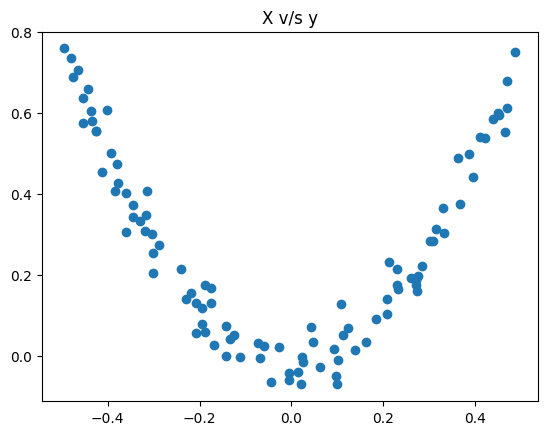

In [10]:
plt.scatter(x = df['X'] , y = df['y'])
plt.title("X v/s y")
plt.show()

### Start Gradient Boosting step by step

In [11]:
# model-1: mean of target. 
df['pred1'] = df['y'].mean()
df.head()

,X,y,pred1
0,-0.125460,0.051573,0.265458
1,0.450714,0.594480,0.265458
2,0.231994,0.166052,0.265458
3,0.098658,-0.070178,0.265458
4,-0.343981,0.343986,0.265458


In [12]:
# calculate residual of model-1
df['res-1'] = df['y'] - df['pred1']
df.head()

,X,y,pred1,res-1
0,-0.125460,0.051573,0.265458,-0.213885
1,0.450714,0.594480,0.265458,0.329021
2,0.231994,0.166052,0.265458,-0.099407
3,0.098658,-0.070178,0.265458,-0.335636
4,-0.343981,0.343986,0.265458,0.078528


In [14]:
# for model-2: 
""" 
  - take a decision tree and send input X and y(target) will be res-1
"""
from sklearn.tree import DecisionTreeRegressor

model2 = DecisionTreeRegressor(max_leaf_nodes = 8) # max_leaf_nodes will be any value from 8 to 32
model2.fit(df['X'].values.reshape(100 , 1) , df['res-1'].values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,8
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [15]:
X_test = np.linspace(-0.5 , 0.5 , 500)

In [16]:
# y_pred = model1 + output of model-2 
model1_output = df['y'].mean()
y_pred = model1_output + model2.predict(X_test.reshape(500 , 1))

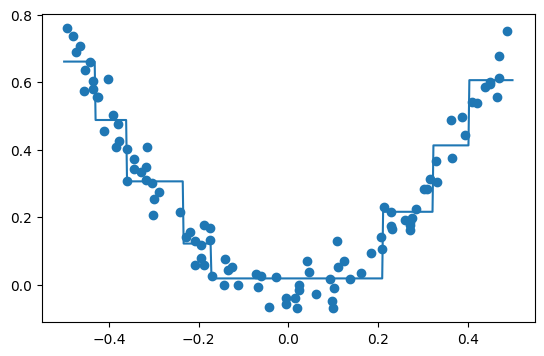

In [17]:
plt.figure(figsize = (14 , 4))
plt.subplot(121)
plt.plot(X_test , y_pred)
plt.scatter(df['X'] , df['y'])
plt.show()

In [18]:
# calculate prediction for model-2 
df['pred2'] = model1_output + model2.predict(df['X'].values.reshape(100 , 1))

In [19]:
df.head()

,X,y,pred1,res-1,pred2
0,-0.125460,0.051573,0.265458,-0.213885,0.018320
1,0.450714,0.594480,0.265458,0.329021,0.605884
2,0.231994,0.166052,0.265458,-0.099407,0.215784
3,0.098658,-0.070178,0.265458,-0.335636,0.018320
4,-0.343981,0.343986,0.265458,0.078528,0.305965


In [20]:
# now calculate the residual for model 2 
df['res-2'] = df['y'] - df['pred2']
df.head()

,X,y,pred1,res-1,pred2,res-2
0,-0.125460,0.051573,0.265458,-0.213885,0.018320,0.033253
1,0.450714,0.594480,0.265458,0.329021,0.605884,-0.011404
2,0.231994,0.166052,0.265458,-0.099407,0.215784,-0.049732
3,0.098658,-0.070178,0.265458,-0.335636,0.018320,-0.088497
4,-0.343981,0.343986,0.265458,0.078528,0.305965,0.038021


In [21]:
# now use another model: model-3 
model3 = DecisionTreeRegressor(max_leaf_nodes = 8)
model3.fit(df['X'].values.reshape(100 , 1) , df['res-2'].values)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,8
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [26]:
# do prediction for model3 
y_pred_model_3 = model1_output +  model2.predict(X_test.reshape(-1 , 1)) +  model3.predict(X_test.reshape(-1 , 1))

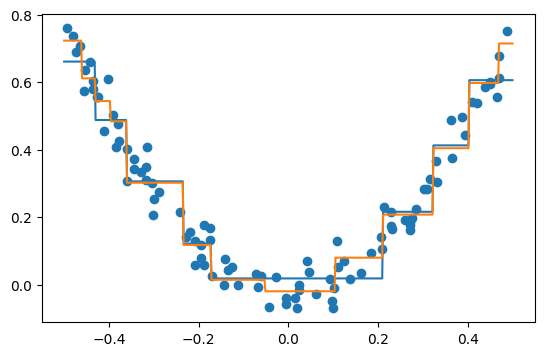

In [27]:
plt.figure(figsize = (14 , 4))
plt.subplot(121)
plt.plot(X_test , y_pred)
plt.plot(X_test , y_pred_model_3)
plt.scatter(df['X'] , df['y'])
plt.show()